In [107]:
import jax
from jax import config
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    config.update("jax_platform_name", "gpu")
    drive.mount("/content/drive")
    %cd /content/drive/MyDrive/NUIN/jaxley_rgc
    !pip install -r requirements.txt
    # Uninstall CPU jax/jaxlib if present
    # !pip uninstall -y jax jaxlib

    # # Install GPU-enabled JAX (choose the right cuda extra for your Colab)
    # # Try cuda12 first (common in Colab recently):
    # !pip install -U "jax[cuda12]"
else: 
    config.update("jax_platform_name", "cpu")

In [108]:
from jax.nn import softplus
import jax.numpy as jnp
from utils.training_utils import K_func, ln_forward, make_rgc_forward_with_states, softplus_beta
from utils.utils import upsample_hold_edges
from utils.v_to_rate import voltage_batch_to_mu, make_edges
from utils.rgc import build_cell, simulate_one_trial, rgc_forward_sim
from utils.spk_detection import voltage_batch_to_spikes, idx_to_times

import matplotlib.pyplot as plt
import jaxley as jx
plt.rcParams["figure.dpi"] = 100
plt.rcParams['axes.labelsize'] = 18

import seaborn as sns
import pandas as pd
pd.set_option('display.max_columns', None)

## To Do:
- Prove with 10s long stim
- Initialize with STA
- Revisar bien training loop y que ycounts/mu_hat have comparable units. 
- mean mu on training loop is super small!!


In [109]:
import jax, jax.numpy as jnp
print("Default backend:", jax.default_backend())
print("Devices:", jax.devices())

x = jnp.arange(10)
print("x placed on:", x.devices() if hasattr(x, "devices") else x.device())



Default backend: cpu
Devices: [CpuDevice(id=0)]
x placed on: {CpuDevice(id=0)}


In [110]:
from utils.stim_utils import generate_1_f_noise, plot_stim

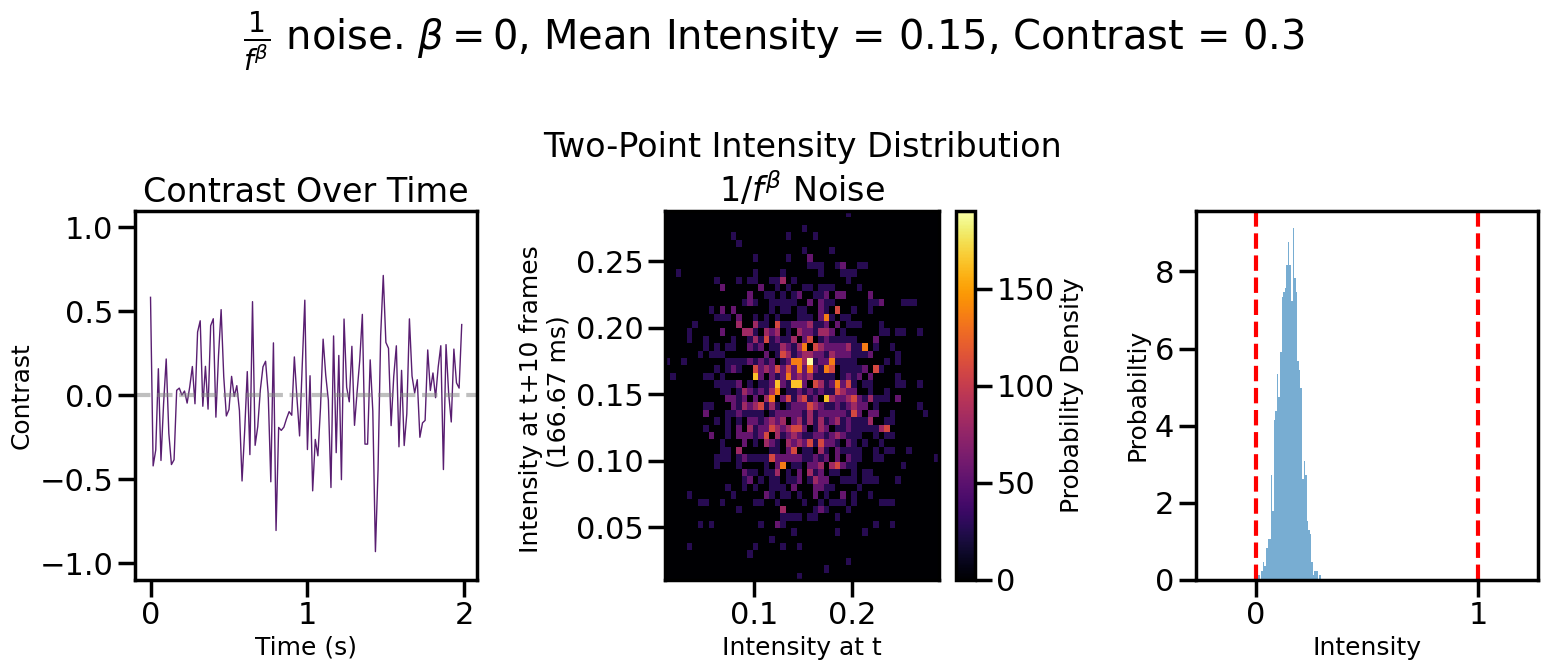

In [111]:
beta= 0
mean_intensity = 0.15
desired_contrast = 0.3
stim_duration = 2
trials = 10
frame_rate = 60
frame_dwell = 1
tau = 10

all_noise = []
all_contrast = []
for trial in range(trials):
    noise, contrast = generate_1_f_noise(
        beta, frame_rate * stim_duration, frame_rate,
        frame_dwell, mean_intensity, desired_contrast,
        noise_seed=trial)
    all_noise.append(noise)
    all_contrast.append(contrast)

noise_t = jnp.concatenate(all_noise)
contrast_t = jnp.concatenate(all_contrast)
stim = jnp.array(all_contrast)

plot_stim(noise_t=noise_t, contrast_mat=stim,
          beta=beta,
          mean_intensity=mean_intensity,
          desired_contrast=desired_contrast,
          tau=10, frame_rate=60, figsize=(16,7))

In [112]:
def softplus_inv(y, eps=1e-8):
    y = jnp.asarray(y, dtype=jnp.float32)
    return jnp.log(jnp.expm1(jnp.maximum(y, eps)))

def ln_params(key,
              alpha_j0,
              alpha_h0,
              logit_tau10,
              logit_tau20,
              beta0,
              gain0,
              shift0,
              noise,
              beta_rate_raw,
              vth_rate):
    eps = noise * jax.random.normal(key, (7,), dtype=jnp.float32)
    return {
      "logit_tau1": jnp.array(logit_tau10, jnp.float32) + eps[0],
      "logit_tau2": jnp.array(logit_tau20, jnp.float32) + eps[1],
      "alpha_j":    jnp.array(alpha_j0,   jnp.float32)  * (1.0 + 0.1*eps[2]),
      "alpha_h":    jnp.array(alpha_h0,   jnp.float32)  * (1.0 + 0.1*eps[3]),
      "log_beta": softplus_inv(beta0) + eps[4],
      "log_gain": softplus_inv(gain0) + eps[5],  # Start with gain ~ 1.0
      "shift":      jnp.array(shift0, jnp.float32) + 0.05*eps[6],
      # "scale": jnp.array(scale, jnp.float32),
      "beta_rate_raw": jnp.array(beta_rate_raw, jnp.float32),
      "vth_rate": jnp.array(vth_rate, jnp.float32),
    }



In [113]:
import matplotlib.cm as cm
cmap = cm.viridis
frame_rate = 60
dt_stim = 1/frame_rate

dt_cell_ms = 0.05
dt_cell_s = dt_cell_ms * 1e-3

R_Mohm = 228.7
dV     = 5.0
key = jax.random.PRNGKey(0)
ground_params = ln_params(key,
                        alpha_j0=0.16,
                        alpha_h0=0.38,
                        logit_tau10=0.55,
                        logit_tau20=-0.57,
                        beta0=0.25,
                        gain0 = 0.4,
                        shift0=0.304,
                        noise=0.05,
                        beta_rate_raw=0.0,
                        vth_rate=-30.0)


filt_dur = 0.6

K_T = int(round(filt_dur / float(dt_stim)))
max_tau = jnp.array(((K_T - 1) / 3.0) * float(dt_stim), dtype=jnp.float32)
drive_ground, L, K_ground =  ln_forward(ground_params, stim, K=K_T, dt=dt_stim, n=6, max_tau=max_tau)


In [115]:
def soft_clip(x, lo, hi):
    mid = 0.5 * (hi + lo)
    half = 0.5 * (hi - lo)
    return mid + half * jnp.tanh((x - mid) / (half + 1e-12))

def current_scale_nA(R_Mohm, dV_mV):
        return dV_mV / R_Mohm  # nA
    
# def current_map(R_Mohm, dV_mV, drive, lo, hi):    
    
#     I_nA = soft_clip(current_scale_nA(R_Mohm, dV_mV) * drive, lo=lo, hi=hi)
#     return I_nA

# def current_map(drive, scale=0.1):
#     return jax.nn.softplus(drive) * scale

def current_map(drive, a=0.1, b=0.02):
    # choose b > a*|min(drive)| so output stays >= 0
    return jnp.maximum(1e-6, b + a * drive)



In [116]:
# I_frame_ground = current_map(R_Mohm, dV, drive_ground, lo=-1.0, hi=1.0)
I_frame_ground = current_map(drive_ground)

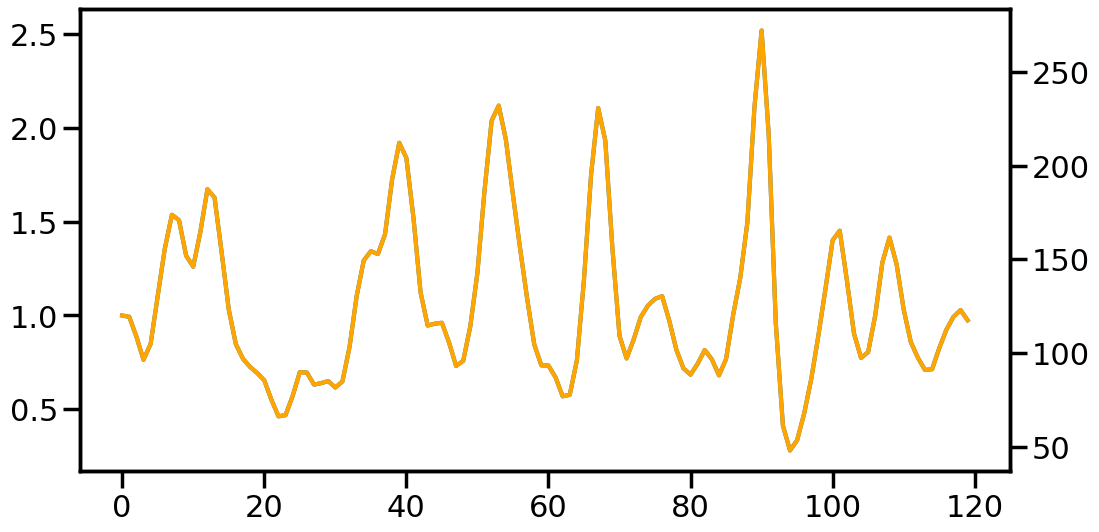

In [117]:
fig, axes = plt.subplots(1,1, figsize=(12,6), sharex=True)
axes.plot(drive_ground[0])
_ = axes.twinx()
_.plot(I_frame_ground[0]*1000, color='orange')

In [118]:
T_f = I_frame_ground.shape[-1]              # number of frames
T_cell = int(round(T_f * dt_stim / dt_cell_s))
I_syn_ground = upsample_hold_edges(I_frame_ground, dt_stim=dt_stim, dt_cell=dt_cell_s, T_cell=T_cell)

# Build cell
cell_ground = build_cell()
cell_ground.delete_recordings()
cell_ground.record("v")
# V_batch = rgc_forward_sim(I_syn_ground, dt_cell_ms, cell_ground)  # dt_cell_ms should be in the same units integrate expects
ground_cell_forward = make_rgc_forward_with_states(cell_ground, dt_cell_ms)
ground_cell_forward = jax.jit(ground_cell_forward)
V_ground            = ground_cell_forward(I_syn_ground)
print(V_ground.shape)

Added 1 recordings. See `.recordings` for details.
(10, 40000)


In [119]:
T_v = V_ground.shape[1]
sr_v = 1.0 / dt_cell_s
r_max_hz = 400
edges_hat = make_edges(T_v, sr_v=sr_v, fr=60.0)
rate_hat, mu_hat = voltage_batch_to_mu(V_ground, edges_hat, sr_v=sr_v, vth=-30, beta=0.5, 
                                       r_max_hz=r_max_hz, vcap=-20)

### Visualize V to rate diff transformation

In [120]:
# fig, axes = plt.subplots(4,1, sharex=True, figsize=(7,7))
# t = jnp.arange(len(V_ground[1])) * dt_cell_s
# t_stim = jnp.arange(len(mu_hat[0]))/60
# axes[0].plot(t_stim, stim[0]) ; axes[0].plot(t_stim, stim[1])
# axes[1].plot(t, V_ground[0]); axes[1].plot(t, V_ground[1])
# axes[1].axhline(-45, ls="--", c='k')
# axes[1].set_ylim(-80, 0)
# axes[2].plot(t, rate_hat[0]) ; axes[2].plot(t, rate_hat[1])

# axes[3].plot(t_stim, mu_hat[0]) ; axes[3].plot(t_stim, mu_hat[1])

# axes[0].set_ylabel("Contrast")
# axes[0].set_ylim(-1,1)
# axes[1].set_ylabel("Vm (mV)")
# axes[2].set_ylabel("Rate \n (Hz)")
# axes[3].set_ylabel("E[count]\n/frame")
# axes[3].set_xlabel("Time (s)")

# fig.tight_layout()

## Spike detection

In [121]:
T_v = V_ground.shape[1]
edges_hat = make_edges(T_v, sr_v=1/dt_cell_s, fr=60.0)


spk_bool, spk_idx_padded, n_spk, spk_train_60 = voltage_batch_to_spikes(
    V_ground,
    dt_v=dt_cell_s,
    edges=edges_hat,
    vth=0.0,        # try 0mV first; if too strict/lenient change to e.g. -10 or +10
    refrac_ms=2.0
)

spk_times_padded = idx_to_times(spk_idx_padded, dt_cell_s)

print("spk_bool:", spk_bool.shape)                 # (50, T_v)
print("spk_train_60:", spk_train_60.shape)         # (50, T_f)
print("n_spk (first 10):", n_spk[:10])


spk_bool: (10, 40000)
spk_train_60: (10, 120)
n_spk (first 10): [44 39 40 47 47 41 38 51 41 42]


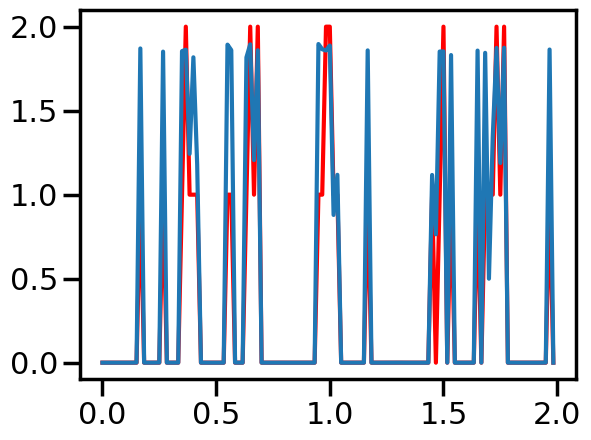

In [122]:
_ = jnp.arange(spk_train_60.shape[1]) / 60
# plt.eventplot(spk_times_padded[2])
plt.plot(_, spk_train_60[2], c='red')
plt.plot(_, mu_hat[2]) 

In [123]:
import matplotlib.cm as cm
cmap = cm.viridis
frame_rate = 60
dt_stim = 1/frame_rate

key2 = jax.random.PRNGKey(1)
# params_ln0 = init_fit_params(key2)
# params_ln0 = ln_params(key2, alpha_j0=1.1,
#                         alpha_h0=0.95,
#                         logit_tau10=1.1,
#                         logit_tau20=1.375,
#                         beta0=0.25,
#                         gain0 = 1.5,
#                         shift0=0.304,
#                         noise=0.05,
#                         beta_rate_raw=0.0,
#                         vth_rate=-30.0)

# params_ln0 = ln_params(key2, alpha_j0=1.1,
#                         alpha_h0=0.95,
#                         logit_tau10=1.1,
#                         logit_tau20=1.375,
#                         beta0=0.25,
#                         gain0 = 0.4,
#                         shift0=0.304,
#                         noise=0.05,
#                         beta_rate_raw=0.0,
#                         vth_rate=-30.0)

params_ln0 = ln_params(key,
                        alpha_j0=0.5,
                        alpha_h0=0.38,
                        logit_tau10=0.7,
                        logit_tau20=-0.85,
                        beta0=0.25,
                        gain0 = 0.4,
                        shift0=0.304,
                        noise=0.05,
                        beta_rate_raw=0.0,
                        vth_rate=-30.0)

filt_dur = 0.6

K_T = int(round(filt_dur / float(dt_stim)))
max_tau = jnp.array(((K_T - 1) / 3.0) * float(dt_stim), dtype=jnp.float32)
drive0, L, K0 =  ln_forward(params_ln0, stim, K=K_T, dt=dt_stim, n=6, max_tau=max_tau)

# Iframe0 = current_map(R_Mohm, dV, drive0, lo=-1.0, hi=1.0)
Iframe0 = current_map(drive0)
T_f = Iframe0.shape[-1]              # number of frames
T_cell = int(round(T_f * dt_stim / dt_cell_s))
I_syn0 = upsample_hold_edges(Iframe0, dt_stim=dt_stim, dt_cell=dt_cell_s, T_cell=T_cell)


In [124]:
cell0 = build_cell()
cell0.delete_recordings()
cell0.record("v")

rgc_forward = make_rgc_forward_with_states(cell0, dt_cell_ms)  # returns a function forward(I_syn)
rgc_forward = jax.jit(rgc_forward)
v0 = rgc_forward(I_syn0).block_until_ready()

Added 1 recordings. See `.recordings` for details.


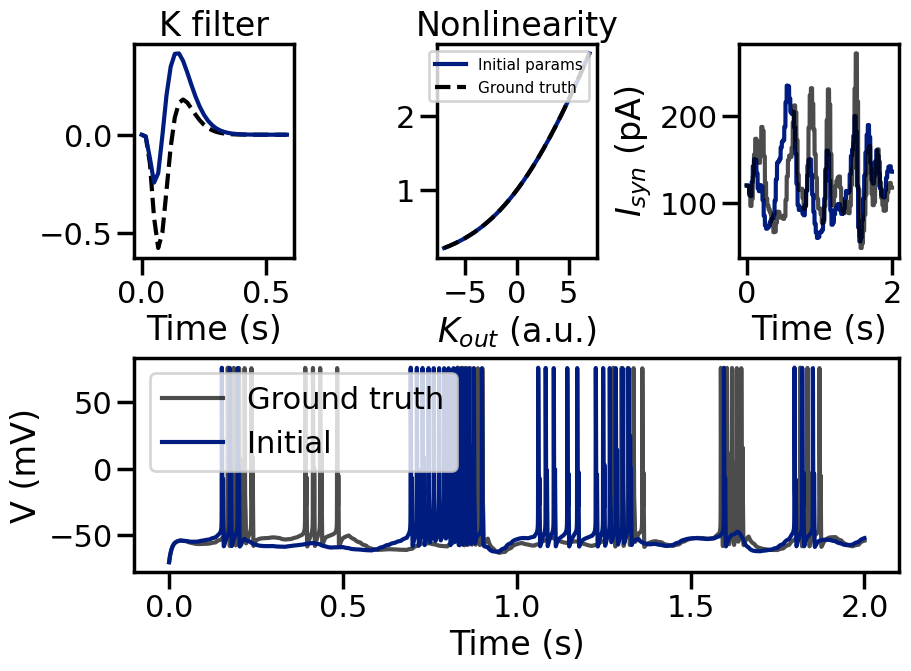

In [125]:
from jax.numpy.linalg import norm

fig = plt.figure(figsize=(6*1.5, 6*1.1), layout="constrained")
gs = fig.add_gridspec(2, 3)

axK  = fig.add_subplot(gs[0, 0])
axNL = fig.add_subplot(gs[0, 1])
axI  = fig.add_subplot(gs[0, 2])
axV  = fig.add_subplot(gs[1, :])  # spans all 3 columns

axK.set_title("K filter")
axK.plot(jnp.arange(len(K_ground))*dt_stim, K_ground/norm(K_ground), c='k', ls="--", label='Ground truth')
axK.plot(jnp.arange(len(K0))*dt_stim,       K0/norm(K0),           c=sns.color_palette("dark")[0], label='Initial params')
axK.set_xlabel("Time (s)")

axNL.set_title("Nonlinearity")
x = jnp.linspace(-7, 7, 300)

beta0  = softplus(params_ln0["log_beta"]) + 1e-6
shift0 = params_ln0["shift"]
gain0  = softplus(params_ln0["log_gain"]) + 1e-6
nl0 = gain0 * softplus_beta(x - shift0, beta=beta0)

beta_g  = softplus(ground_params["log_beta"]) + 1e-6
shift_g = ground_params["shift"]
gain_g  = softplus(ground_params["log_gain"]) + 1e-6
nl_g = gain_g * softplus_beta(x - shift_g, beta=beta_g)

axNL.plot(x, nl0, label='Initial params', c=sns.color_palette("dark")[0])
axNL.plot(x, nl_g, c='k', ls="--", label='Ground truth')
axNL.set_xlabel(r"$K_{out}$ (a.u.)")
# axNL.set_ylabel(r"$I_{syn}$ (pA)")
axNL.legend(loc='upper right', fontsize=11)

t = jnp.arange(len(I_syn0[0])) * dt_cell_s
axI.plot(t, I_syn0[0]*1000, c=sns.color_palette("dark")[0])
axI.plot(t, I_syn_ground[0]*1000, c='k', alpha=0.7)
axI.set_ylabel(r"$I_{syn}$ (pA)")
axI.set_xlabel("Time (s)")

axV.plot(t, V_ground[1], c='k', alpha=0.7, label="Ground truth")
axV.plot(t, v0[1], c=sns.color_palette("dark")[0], label="Initial")  # if you want it
axV.set_xlabel("Time (s)")
axV.set_ylabel("V (mV)")
axV.legend()


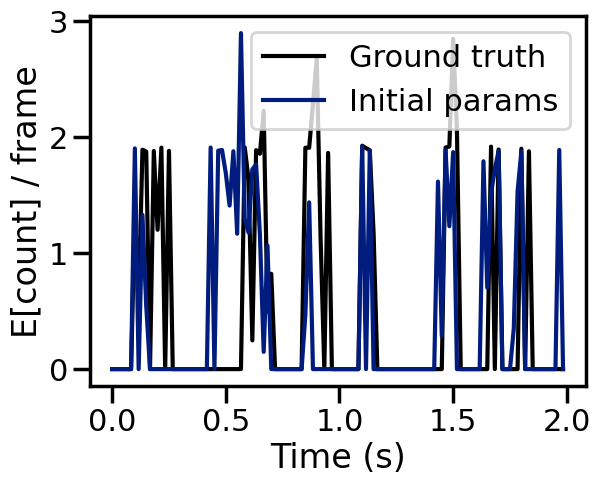

In [126]:
mu_ground = predict_mu_from_params(ground_params, stim, r_max_hz=r_max_hz, sr_v=sr_v)
mu0 = predict_mu_from_params(params_ln0, stim, r_max_hz=r_max_hz, sr_v=sr_v)
t_stim = jnp.arange(len(mu_ground[0])) / 60
plt.plot(t_stim, mu_ground[0], c='k', label='Ground truth')
plt.plot(t_stim, mu0[0], c=sns.color_palette("dark")[0], label='Initial params')
plt.xlabel("Time (s)")
plt.ylabel("E[count] / frame")
plt.legend()

In [127]:
print(jnp.mean(mu_ground), jnp.mean(mu0[:5,:]))

0.47656178 0.46365002


In [128]:
def poisson_nll(mu, y, eps=1e-8):
    mu = jnp.clip(mu, eps, 1e9)
    return jnp.mean(mu - y * jnp.log(mu))  # + const (ignored)


import optax


def predict_mu_from_params(params, stim, r_max_hz, sr_v):
    # 1) LN
    drive, _, _ = ln_forward(params, stim, K=K_T, dt=dt_stim, n=6, max_tau=max_tau)
    # I_frame = current_map(R_Mohm, dV, drive, lo=0.0, hi=1.0)
    I_frame = current_map(drive)
    # 3) Upsample to cell timestep
    T_f = I_frame.shape[-1]
    T_cell = int(round(T_f * dt_stim / dt_cell_s))
    I_syn = upsample_hold_edges(I_frame, dt_stim=dt_stim, dt_cell=dt_cell_s, T_cell=T_cell)  # (B, T_v)

    # 4) Biophysical RGC voltage (uses captured cell + states)
    V_batch = rgc_forward(I_syn)  # (B, T_v)

    # 5) Voltage -> rate -> mu/frame (use learnable head)
    beta_rate = jax.nn.softplus(params["beta_rate_raw"]) + 1e-3
    vth_rate  = params["vth_rate"]

    rate_batch, mu_batch = voltage_batch_to_mu(
        V_batch, edges_hat, sr_v=sr_v,
        vth=vth_rate, beta=beta_rate, r_max_hz=r_max_hz, vcap=-20
    )
    return mu_batch



In [129]:
import jax
import jax.numpy as jnp
import optax
from jax.nn import softplus

# y_counts = spk_train_60.astype(jnp.float32)
y_counts = mu_ground.astype(jnp.float32)
# -------------------------
# Priors / penalty settings
# -------------------------
BETA_PRIOR    = 0.25
SIGMA_LOGBETA = 1.0
LAM_BETA      = 1e-2

# SIGMA_MEAN    = 0.1
# LAM_MEAN      = 0.1


def beta_from_params(params, eps=1e-6):
    return softplus(params["log_beta"]) + eps

def beta_prior_penalty(params, beta_prior=BETA_PRIOR, sigma_logbeta=SIGMA_LOGBETA):
    beta = beta_from_params(params)
    logb  = jnp.log(beta)
    logb0 = jnp.log(jnp.asarray(beta_prior, dtype=logb.dtype))
    return ((logb - logb0) / sigma_logbeta) ** 2

# def mean_rate_penalty(mu_hat, y_counts, sigma_mean=SIGMA_MEAN):
#     dm = jnp.mean(mu_hat) - jnp.mean(y_counts)
#     return (dm / sigma_mean) ** 2


def loss_fn_with_priors(params, stim, y_counts, r_max_hz, sr_v):
    mu_hat = predict_mu_from_params(params, stim, sr_v=sr_v, r_max_hz=r_max_hz)
    data = poisson_nll(mu_hat, y_counts)
    reg_beta = beta_prior_penalty(params)
    # reg_mean = mean_rate_penalty(mu_hat, y_counts)
    return data + LAM_BETA * reg_beta #+ LAM_MEAN * reg_mean


# -------------------------
# Optimizer with FROZEN head
# -------------------------
FREEZE_KEYS = {"beta_rate_raw", "vth_rate", "log_beta", "log_gain", "shift"}
# FREEZE_KEYS = {"beta_rate_raw", "vth_rate", "log_beta"}

def label_fn(path, v):
    k0 = path[0]
    k = k0.key if hasattr(k0, "key") else str(k0)
    if k in FREEZE_KEYS: return "frozen"
    if k == "shift":     return "shift"
    if k == "log_gain":  return "gain"
    return "ln"

param_labels = jax.tree_util.tree_map_with_path(label_fn, params_ln0)

tx = optax.multi_transform(
    {
        "ln":     optax.chain(optax.clip_by_global_norm(1.0), optax.adam(1e-3)),
        "shift":  optax.chain(optax.clip_by_global_norm(1.0), optax.adam(1e-4)),
        "gain":   optax.chain(optax.clip_by_global_norm(1.0), optax.adam(1e-3)),
        "frozen": optax.set_to_zero(),
    },
    param_labels
)

opt_state = tx.init(params_ln0)

batch_size = 10

@jax.jit
def train_step_minibatch(params, opt_state, stim, y_counts, key, r_max_hz, sr_v):
    B_total = stim.shape[0]
    idx = jax.random.randint(key, (batch_size,), 0, B_total)
    stim_b = stim[idx]
    y_b    = y_counts[idx]

    loss, grads = jax.value_and_grad(loss_fn_with_priors)(params, stim_b, y_b, r_max_hz=r_max_hz, sr_v=sr_v)
    updates, opt_state = tx.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss


## Train

In [130]:
from jax.tree_util import tree_map_with_path

def key_from_path(path):
    k0 = path[0]
    return k0.key if hasattr(k0, "key") else str(k0)

labels = tree_map_with_path(lambda p, v: label_fn(p, v), params_ln0)

print("Param labels:")
for k, lab in labels.items():
    print(f"{k:15s} -> {lab}")


Param labels:
alpha_h         -> ln
alpha_j         -> ln
beta_rate_raw   -> frozen
log_beta        -> frozen
log_gain        -> frozen
logit_tau1      -> ln
logit_tau2      -> ln
shift           -> frozen
vth_rate        -> frozen


In [131]:
y = y_counts
mu0 = jnp.full_like(y, jnp.mean(y))
base_nll = poisson_nll(mu0, y)

# initial model loss (data term only)
mu_init = predict_mu_from_params(params_ln0, stim, r_max_hz=r_max_hz, sr_v=sr_v)
init_nll = poisson_nll(mu_init, y)

# initial full objective (data + priors)
init_full = loss_fn_with_priors(params_ln0, stim, y, r_max_hz=r_max_hz, sr_v=sr_v)

print("baseline nll:", float(base_nll))
print("init model nll:", float(init_nll))
print("init full loss:", float(init_full))
print("mean(mu_init):", float(jnp.mean(mu_init)), "mean(y):", float(jnp.mean(y)))
print("beta_init:", float(beta_from_params(params_ln0)), "gain_init:", float(softplus(params_ln0["log_gain"]) + 1e-6))


baseline nll: 0.8297696709632874
init model nll: 3.916059732437134
init full loss: 3.916060447692871
mean(mu_init): 0.45025286078453064 mean(y): 0.4765617847442627
beta_init: 0.2519552707672119 gain_init: 0.38423657417297363


In [132]:
def predict_V_from_params(params, stim):
    drive, _, _ = ln_forward(params, stim, K=K_T, dt=dt_stim, n=6, max_tau=max_tau)
    # I_frame = current_map(R_Mohm, dV, drive, lo=-1.0, hi=1.0)
    I_frame = current_map(drive)
    T_f = I_frame.shape[-1]
    T_cell = int(round(T_f * dt_stim / dt_cell_s))
    I_syn = upsample_hold_edges(I_frame, dt_stim=dt_stim, dt_cell=dt_cell_s, T_cell=T_cell)
    return rgc_forward(I_syn)
V = predict_V_from_params(params_ln0, stim[:2])
print("V train-path mean/std/min/max:",
      float(jnp.mean(V)), float(jnp.std(V)), float(jnp.min(V)), float(jnp.max(V)))


V train-path mean/std/min/max: -50.8072624206543 17.92062759399414 -70.24829864501953 75.88545989990234


In [133]:
key = jax.random.PRNGKey(0)
key, sub = jax.random.split(key)

p0 = params_ln0
p1, opt_state, loss = train_step_minibatch(p0, opt_state, stim, y_counts, sub, r_max_hz=r_max_hz, sr_v=sr_v)

for k in ["shift","log_beta","log_gain","alpha_j","alpha_h","logit_tau1","logit_tau2","beta_rate_raw","vth_rate"]:
    d = float(jnp.max(jnp.abs(jnp.ravel(p1[k] - p0[k]))))
    print(k, "max|Δ|", d)


shift max|Δ| 0.0
log_beta max|Δ| 0.0
log_gain max|Δ| 0.0
alpha_j max|Δ| 0.0009999871253967285
alpha_h max|Δ| 0.0009999871253967285
logit_tau1 max|Δ| 0.0009999871253967285
logit_tau2 max|Δ| 0.0009999871253967285
beta_rate_raw max|Δ| 0.0
vth_rate max|Δ| 0.0


In [134]:
log_every = 25
n_steps = 500
n_logs = n_steps // log_every + 1

loss_log = jnp.zeros((n_logs,), dtype=jnp.float32)
log_i = 0

params = params_ln0
key = jax.random.PRNGKey(0)
for it in range(n_steps):
    key, sub = jax.random.split(key)
    params, opt_state, loss = train_step_minibatch(
        params, opt_state, stim, y_counts,
        sub, r_max_hz=r_max_hz, sr_v=sr_v
    )

    if it % log_every == 0:
        loss_log = loss_log.at[log_i].set(loss.astype(jnp.float32))
        print(it, float(jax.device_get(loss)))

        mu_hat_dbg = predict_mu_from_params(params, stim, r_max_hz=r_max_hz, sr_v=sr_v)
        print("beta", float(beta_from_params(params)),
              "reg_beta", float(beta_prior_penalty(params)),
              # "reg_mean", float(mean_rate_penalty(mu_hat_dbg, y_counts[:2])),
              "mean(mu)", float(jnp.mean(mu_hat_dbg)),
              "mean(y)", float(jnp.mean(y_counts)))

        log_i += 1

loss_log_np = jax.device_get(loss_log)



0 3.633631467819214
beta 0.2519552707672119 reg_beta 6.0694768762914464e-05 mean(mu) 0.449896901845932 mean(y) 0.4765617847442627
25 3.8663744926452637
beta 0.2519552707672119 reg_beta 6.0694768762914464e-05 mean(mu) 0.4430142343044281 mean(y) 0.4765617847442627
50 4.062352180480957
beta 0.2519552707672119 reg_beta 6.0694768762914464e-05 mean(mu) 0.45039552450180054 mean(y) 0.4765617847442627
75 3.5588150024414062
beta 0.2519552707672119 reg_beta 6.0694768762914464e-05 mean(mu) 0.4527851939201355 mean(y) 0.4765617847442627
100 3.549481153488159
beta 0.2519552707672119 reg_beta 6.0694768762914464e-05 mean(mu) 0.45655232667922974 mean(y) 0.4765617847442627


KeyboardInterrupt: 

In [ ]:
mu_hat = predict_mu_from_params(params, stim, r_max_hz=r_max_hz, sr_v=sr_v)
data = poisson_nll(mu_hat, y_counts)
reg_beta = beta_prior_penalty(params)
# reg_mean = mean_rate_penalty(mu_hat, y_counts)

print("data", float(data))
print("reg_beta", float(reg_beta), "weighted", float(LAM_BETA * reg_beta))
# print("reg_mean", float(reg_mean), "weighted", float(LAM_MEAN * reg_mean))
print("mean(mu)", float(jnp.mean(mu_hat)), "mean(y)", float(jnp.mean(y_counts)))
print("beta", float(beta_from_params(params)))



In [ ]:
loss, grads = jax.value_and_grad(loss_fn_with_priors)(params, stim, y_counts, r_max_hz=r_max_hz, sr_v=sr_v)

def gnorm(x):
    return float(jax.device_get(jnp.linalg.norm(jnp.ravel(x))))

for k in ["logit_tau1","logit_tau2","alpha_j","alpha_h","log_beta","shift", "log_gain","beta_rate_raw","vth_rate"]:
    print(k, gnorm(grads[k]), " param:", float(jax.device_get(params[k])))
print("loss:", float(jax.device_get(loss)))


In [ ]:
def loss_data(p):
    mu = predict_mu_from_params(p, stim, r_max_hz=r_max_hz, sr_v=sr_v)
    return poisson_nll(mu, y_counts)

loss_d, grads_d = jax.value_and_grad(loss_data)(params)

for k in ["shift","log_beta","alpha_j","alpha_h","logit_tau1","logit_tau2"]:
    print(k, "grad_data", gnorm(grads_d[k]))



In [ ]:
drive, L, k = ln_forward(params, stim[:2], K=K_T, dt=dt_stim, n=6, max_tau=max_tau)
norm_k = jnp.sqrt(jnp.sum(k**2) * dt_stim)
print("norm_k:", float(norm_k))
print("k max/min:", float(jnp.max(k)), float(jnp.min(k)))


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import jax
# import jax.numpy as jnp

# # pick which params to track
# track_keys = ["logit_tau1","logit_tau2","alpha_j","alpha_h","log_beta","shift","DC","scale","beta_rate_raw","vth_rate"]

# def snapshot(params, keys):
#     # convert to plain python floats for easy plotting
#     out = {}
#     for k in keys:
#         out[k] = float(jax.device_get(params[k]))
#     return out

# # storage
# hist = {k: [] for k in track_keys}
# loss_hist = []

# opt_state = optimizer.init(params)

# # compile once
# train_step = jax.jit(train_step)

# log_every = 25

# loss_hist = []
# hist = {k: [] for k in track_keys}

# for it in range(301):
#     params, opt_state, loss = train_step(params, opt_state, stim, y_counts)

#     if it % log_every == 0:
#         loss_val = float(jax.device_get(loss))   # sync only occasionally
#         print(it, loss_val)
#         loss_hist.append(loss_val)

#         snap = snapshot(params, track_keys)      # only occasionally
#         for k in track_keys:
#             hist[k].append(snap[k])


In [ ]:
# # Run one forward pass (no jit) and inspect devices
# drive, _, _ = ln_forward(params, stim, K=K_T, dt=dt_stim, n=6, max_tau=max_tau)
# I_frame = current_map(drive, params)
# T_f = I_frame.shape[-1]
# T_cell = int(round(T_f * dt_stim / dt_cell_s))
# I_syn = upsample_hold_edges(I_frame, dt_stim=dt_stim, dt_cell=dt_cell_s, T_cell=T_cell)

# print("I_syn device:", I_syn.device if hasattr(I_syn, "device") else "host")

# V_batch = rgc_forward(I_syn)
# print("V_batch device:", V_batch.device if hasattr(V_batch, "device") else "host")

# mu = predict_mu_from_params(params, stim)
# print("mu device:", mu.device if hasattr(mu, "device") else "host")

# loss0 = loss_fn(params, stim, y_counts)
# print("loss device:", loss0.device if hasattr(loss0, "device") else "host")


In [ ]:
# ---- loss ----
plt.figure()
plt.plot(loss_hist)
plt.xlabel("iteration")
plt.ylabel("Poisson NLL")
plt.title("Training loss")
plt.show()

# ---- params (small multiples) ----
keys_to_plot = ["logit_tau1","logit_tau2","alpha_j","alpha_h","log_beta","shift","DC","scale","beta_rate_raw","vth_rate"]

n = len(keys_to_plot)
ncols = 3
nrows = int(np.ceil(n / ncols))

plt.figure(figsize=(12, 3*nrows))
for i, k in enumerate(keys_to_plot, 1):
    plt.subplot(nrows, ncols, i)
    plt.plot(hist[k])
    plt.title(k)
    plt.xlabel("iteration")
plt.tight_layout()
plt.show()


In [ ]:
loss, grads = jax.value_and_grad(loss_fn)(params, stim, y_counts)

def gnorm(x):
    return float(jax.device_get(jnp.linalg.norm(jnp.ravel(x))))

for k in ["logit_tau1","logit_tau2","alpha_j","alpha_h","log_beta","shift","DC","scale","beta_rate_raw","vth_rate"]:
    print(k, gnorm(grads[k]), " param:", float(jax.device_get(params[k])))
print("loss:", float(jax.device_get(loss)))


In [ ]:
k, L, drive, beta, shift, tau_j, tau_h = get_ln_objects(
        params, stim, K_T=K_T, dt_stim=dt_stim, n=6, max_tau=max_tau
    )

k_np = np.array(jax.device_get(k))



In [ ]:
from jax.numpy.linalg import norm
t_k = jnp.arange(len(drive[0]))/frame_rate
# sns.set_palette("dark")
fig, axes = plt.subplots(1, 2, figsize=(6*1.1, 4*1.1),  layout="constrained")


axes[0].plot(jnp.arange(len(K_ground))*dt_stim, K_ground/norm(K_ground), c='k', ls="--", label='Ground truth',)

axes[0].plot(jnp.arange(len(K0))*dt_stim, K0/norm(K0), c=sns.color_palette("dark")[0], label='Initial params')
axes[0].plot(np.arange(len(k_np)) * float(dt_stim) , k_np/norm(k_np), label="learned")
axes[0].set_xlabel("Time (s)")
axes[0].set_title("K filter")

axes[1].set_title("Nonlinearity")

x = jnp.linspace(-7, 7, 300)

beta0  = softplus(params_ln0["log_beta"]) + 1e-6
shift0 = params_ln0["shift"]
nl0 = softplus(beta0 * (x - shift0))

beta_ground  = softplus(ground_params["log_beta"]) + 1e-6
shift_ground = ground_params["shift"]
nl_ground = softplus(beta_ground * (x - shift_ground))


beta_learned  = softplus(params["log_beta"]) + 1e-6
shift_learned = params["shift"]
nl_learned = softplus(beta_learned * (x - shift_learned))

axes[1].plot(x, nl0, label='Initial params', c=sns.color_palette("dark")[0])
axes[1].plot(x, nl_ground ,c='k', ls="--", label='Ground truth')
axes[1].plot(x, nl_learned, )
axes[1].set_xlabel(r"$K_{out}$ (a.u.)")
axes[0].legend(loc= 'upper right', fontsize=11)
fig.tight_layout(w_pad=0.1)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax.nn import sigmoid, softplus

def get_ln_objects(params, stim, *, K_T, dt_stim, n, max_tau):
    # tau in seconds (since dt_stim is seconds)
    tau_j = sigmoid(params["logit_tau1"]) * max_tau
    tau_h = sigmoid(params["logit_tau2"]) * max_tau

    k = K_func(tau_j, tau_h, n, params["alpha_j"], params["alpha_h"], K_T, dt_stim)

    # L2 normalization (same as your ln_forward)
    eps = 1e-12
    k = k / (jnp.sqrt(jnp.sum(k**2) * dt_stim) + eps)

    # linear stage
    def conv1(tr):
        return jnp.convolve(tr, k, mode="full")[:tr.shape[0]]

    L = jax.vmap(conv1)(stim) if stim.ndim == 2 else conv1(stim)

    # nonlinearity params
    beta  = softplus(params["log_beta"]) + 1e-6
    shift = params["shift"]

    # drive
    drive = softplus(beta * (L - shift))
    return k, L, drive, beta, shift, tau_j, tau_h

def plot_filter_and_nl(params, stim, *, K_T, dt_stim, n, max_tau, title="LN"):
    k, L, drive, beta, shift, tau_j, tau_h = get_ln_objects(
        params, stim, K_T=K_T, dt_stim=dt_stim, n=n, max_tau=max_tau
    )

    # --- Filter plot ---
    t = np.arange(K_T) * float(dt_stim)  # seconds
    k_np = np.array(jax.device_get(k))

    plt.figure(figsize=(10,4))
    plt.plot(t, k_np)
    plt.xlabel("time (s)")
    plt.ylabel("k(t)")
    plt.title(f"{title} filter  |  tau_j={float(tau_j):.3f}s, tau_h={float(tau_h):.3f}s")
    plt.axhline(0, linewidth=1)
    plt.show()

    # --- NL curve plot ---
    # choose x-range from L distribution
    L_np = np.array(jax.device_get(L)).ravel()
    lo, hi = np.percentile(L_np, [1, 99])
    x = np.linspace(lo, hi, 400).astype(np.float32)

    beta_f  = float(jax.device_get(beta))
    shift_f = float(jax.device_get(shift))

    y = np.array(jax.device_get(softplus(beta * (jnp.array(x) - shift))))

    plt.figure(figsize=(10,4))
    plt.plot(x, y)
    plt.xlabel("Linear output L")
    plt.ylabel("drive = softplus(beta*(L-shift))")
    plt.title(f"{title} nonlinearity  |  beta={beta_f:.3f}, shift={shift_f:.3f}")
    plt.show()

    # --- Empirical LN scatter (optional but useful) ---
    drive_np = np.array(jax.device_get(drive)).ravel()

    plt.figure(figsize=(6,6))
    # subsample to keep it light
    idx = np.random.RandomState(0).choice(L_np.size, size=min(5000, L_np.size), replace=False)
    plt.scatter(L_np[idx], drive_np[idx], s=4, alpha=0.2)
    plt.xlabel("L")
    plt.ylabel("drive")
    plt.title(f"{title} empirical LN mapping (subsample)")
    plt.show()

plot_filter_and_nl(params, stim, K_T=K_T, dt_stim=dt_stim, n=6, max_tau=max_tau, title="Trained LN")
